<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_MutliClassClassification/18_5_1_Multiclass_Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Classification: Part 1
## When Two Classes Are Not Enough

---

## What This Notebook Is About

The last two units built a complete binary classification toolkit. You can detect fraud or not, predict churn or not, classify a patient as high-risk or low-risk. The model outputs one probability, you pick a threshold, done.

But the world rarely fits into two buckets.

- A doctor does not just ask "sick or not?" — they ask "which condition?"
- A plant biologist does not just ask "plant or not?" — they ask "which species?"
- A streaming service does not just ask "will they cancel?" — they ask "which plan will they switch to?"

This notebook introduces **multiclass classification**: problems with three or more possible outcomes. By the end, you will know how to train a multiclass model, interpret its probability outputs, and read the expanded confusion matrix.

**What you will learn:**
1. How a multiclass problem differs from a binary one
2. How XGBoost handles more than two classes without major code changes
3. What `predict_proba()` returns when there are three classes
4. How to read a 3×3 confusion matrix

## Setup

We will use the **Palmer Penguins** dataset — the same penguins from Unit 17, where you predicted body mass. This time, you will predict the *species*: Adelie, Chinstrap, or Gentoo.

That is a meaningful upgrade. Before, you were estimating a continuous number. Now you are classifying each penguin into one of three groups. Same data, completely different question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                              accuracy_score, confusion_matrix)

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(url)

print(f"Rows: {penguins.shape[0]}, Columns: {penguins.shape[1]}")
penguins.head()

Rows: 344, Columns: 7


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


---

## Section 1: Getting to Know the Problem

### The Scenario

Imagine you are a wildlife researcher on a remote Antarctic island. You have just measured a penguin — its bill length, bill depth, flipper length, body mass, and the island it came from. You need to record the species, but the penguin has waddled off before you could write it down.

Can the measurements tell you which species it was? That is exactly what we are going to find out.

### The Three Species

- **Adelie** — the most common; short, stubby bills; found on all three islands
- **Chinstrap** — named for the thin black band under their chin; longer, narrower bills
- **Gentoo** — the tallest; distinctive orange-red bill; largest body mass

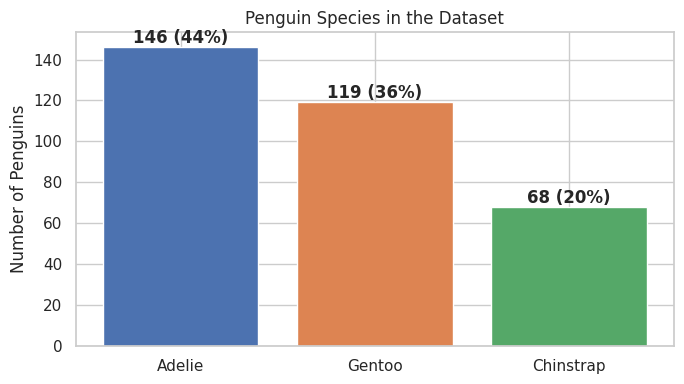

Total penguins: 333
Naive baseline (always guess Adelie): 43.8%


In [2]:
penguins = penguins.dropna().reset_index(drop=True)

species_counts = penguins["species"].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(species_counts.index, species_counts.values, color=colors, edgecolor="white")
for i, (name, count) in enumerate(species_counts.items()):
    ax.text(i, count + 2, f"{count} ({count/len(penguins):.0%})",
            ha="center", fontweight="bold")
ax.set_ylabel("Number of Penguins")
ax.set_title("Penguin Species in the Dataset")
plt.tight_layout()
plt.show()

naive_baseline = species_counts.iloc[0] / len(penguins)
print(f"Total penguins: {len(penguins)}")
print(f"Naive baseline (always guess Adelie): {naive_baseline:.1%}")

Adelie makes up 44% of the dataset. A model that always guessed "Adelie" would be right 44% of the time. That is our floor to beat.

### Are the Species Visually Separable?

Before building any model, look at the data. If the three species form distinct clusters in the feature space, a classifier has a fighting chance. If they are hopelessly tangled, no model will help.

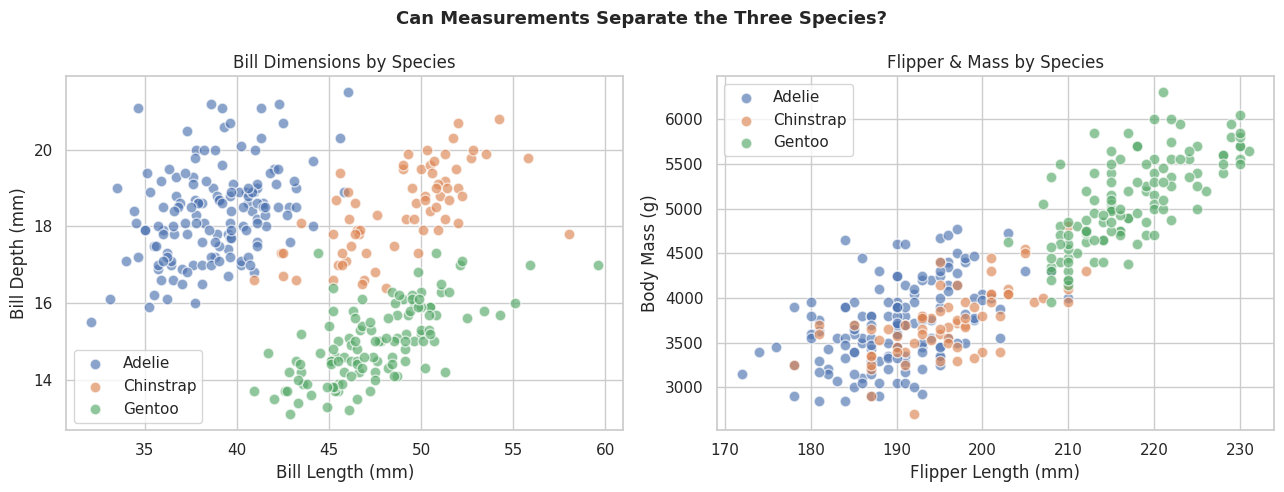

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for species, color in zip(["Adelie", "Chinstrap", "Gentoo"], colors):
    subset = penguins[penguins["species"] == species]
    axes[0].scatter(subset["bill_length_mm"], subset["bill_depth_mm"],
                   label=species, color=color, alpha=0.65, edgecolors="white", s=60)
    axes[1].scatter(subset["flipper_length_mm"], subset["body_mass_g"],
                   label=species, color=color, alpha=0.65, edgecolors="white", s=60)

for ax, (xlabel, ylabel, title) in zip(axes, [
    ("Bill Length (mm)", "Bill Depth (mm)", "Bill Dimensions by Species"),
    ("Flipper Length (mm)", "Body Mass (g)", "Flipper & Mass by Species"),
]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.suptitle("Can Measurements Separate the Three Species?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Look at the left plot. Adelie and Chinstrap have similar body sizes — they tangle together in flipper/mass space. But they pull apart on bill dimensions: Chinstrap has a longer, narrower bill.

Gentoo forms its own island in both plots.

This is the core challenge of multiclass classification: "not Gentoo" still leaves two possible species that require different features to separate. A good classifier has to learn that lesson.

## Section 2: Preparing the Data

XGBoost needs numeric inputs. The two text columns — `island` and `sex` — get one-hot encoded. The target `species` gets mapped to integers 0, 1, 2.

**A note on target encoding conventions.** Tree-based models like XGBoost are happy with integer-encoded targets (0, 1, 2). Neural networks, by contrast, typically expect targets to be **one-hot encoded** — a vector of zeros with a single 1 in the position of the true class. For three species: Adelie = [1, 0, 0], Chinstrap = [0, 1, 0], Gentoo = [0, 0, 1]. Most deep-learning frameworks (PyTorch, Keras) handle this conversion automatically, but the convention is worth knowing before you encounter it.

In [4]:
species_names = ["Adelie", "Chinstrap", "Gentoo"]
species_map = {name: i for i, name in enumerate(species_names)}

y = penguins["species"].map(species_map).to_numpy()

features = pd.get_dummies(
    penguins.drop(columns=["species"]),
    columns=["island", "sex"],
    drop_first=False
)
X = features.to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features         : {X.shape[1]}")

Training samples : 266
Test samples     : 67
Features         : 9


## Section 3: Training a Multiclass Model

Here is the key insight: **you barely have to change the code**.

In binary classification, XGBoost estimated one probability — P(fraud) or P(churn). For three classes, it estimates three probabilities:

- P(Adelie | measurements)
- P(Chinstrap | measurements)
- P(Gentoo | measurements)

These three numbers always add up to 1.0. The predicted class is whichever is highest.

The only code change: set `objective="multi:softprob"` and tell XGBoost how many classes to expect with `num_class=3`.

**Under the hood — softmax.** Internally, XGBoost computes a raw score for each class and then passes those scores through a function called **softmax**, which converts them into probabilities that sum to 1.0. Softmax is not unique to XGBoost — it is the standard output activation for multiclass classifiers, and you will encounter it again as the final layer of a multiclass neural network.

**The training objective — log-loss.** The `eval_metric="mlogloss"` argument tracks **log-loss** (also called *cross-entropy loss*). This metric measures how well the model's probability estimates match the true class labels: the closer each predicted probability is to 1.0 for the correct class, the lower the loss. Cross-entropy is also the standard training objective for neural network classifiers — another concept that carries over directly.

In [5]:
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Naive baseline (always predict Adelie): {naive_baseline:.1%}")
print(f"XGBoost accuracy                      : {accuracy:.1%}")
print(f"Improvement over baseline             : {accuracy - naive_baseline:+.1%}")

Naive baseline (always predict Adelie): 43.8%
XGBoost accuracy                      : 100.0%
Improvement over baseline             : +56.2%


The model substantially outperforms guessing "Adelie" every time. But accuracy is just a single number. To understand *how* the model performs on each species, we need probabilities and the confusion matrix.

---

## Section 4: Probabilities for Three Classes

In binary classification, `predict_proba()` returned two columns — one for class 0 and one for class 1. They summed to 1, so you usually only used the second column.

With three classes, `predict_proba()` returns **three columns**: one probability per species per row. Look at a sample to build your intuition.

In [6]:
probs = model.predict_proba(X_test)

# Build a readable display table
prob_df = pd.DataFrame(
    probs,
    columns=[f"P({name})" for name in species_names]
).round(3)
prob_df.insert(0, "Actual",    [species_names[i] for i in y_test])
prob_df.insert(1, "Predicted", [species_names[i] for i in y_pred])
prob_df.insert(2, "Correct",   (prob_df["Predicted"] == prob_df["Actual"]))

# Show a mix of correct and incorrect predictions
wrong_idx  = prob_df[~prob_df["Correct"]].index.tolist()[:3]
right_idx  = prob_df[prob_df["Correct"]].index.tolist()[:5]
sample_idx = sorted(set(wrong_idx + right_idx))[:10]

prob_df.loc[sample_idx]

,Actual,Predicted,Correct,P(Adelie),P(Chinstrap),P(Gentoo)
0,Gentoo,Gentoo,True,0.001,0.001,0.997
1,Chinstrap,Chinstrap,True,0.002,0.996,0.002
2,Adelie,Adelie,True,0.998,0.001,0.001
3,Gentoo,Gentoo,True,0.002,0.002,0.997
4,Gentoo,Gentoo,True,0.001,0.001,0.997


Study the rows.

When the model is **confident**, one probability is near 1.0 and the others are near 0.0. When it is **uncertain**, the probability spreads out — maybe 0.55 / 0.35 / 0.10.

Notice that **the three probabilities always sum to 1.0**. The model distributes 100% of its confidence across the three possible species.

In binary classification, you often tune the decision threshold — lower it to catch more positives. In multiclass, the default rule (take the highest probability) is almost always what you want. The winner takes all.

**Looking ahead to neural networks.** A multiclass neural network's output layer does exactly what you are seeing here: it applies softmax to produce one probability per class, and the highest wins. The N×K table you get from `predict_proba()` is the same format as the raw output of a trained multiclass neural network. When you build one, the output will feel immediately familiar.

---

## Section 5: The 3×3 Confusion Matrix

### From 2×2 to 3×3

In binary classification, the confusion matrix was 2×2: four cells covering every combination of actual and predicted class. With three classes, it extends to 3×3: nine cells.

The logic is identical:

- **Rows** are the *actual* species
- **Columns** are the *predicted* species
- **Diagonal cells** (top-left to bottom-right) are correct predictions
- **Off-diagonal cells** are mistakes — the position tells you exactly which mistake

Row "Adelie", column "Chinstrap" means: how many actual Adelie penguins were mislabeled as Chinstrap? That is information accuracy alone cannot give you.

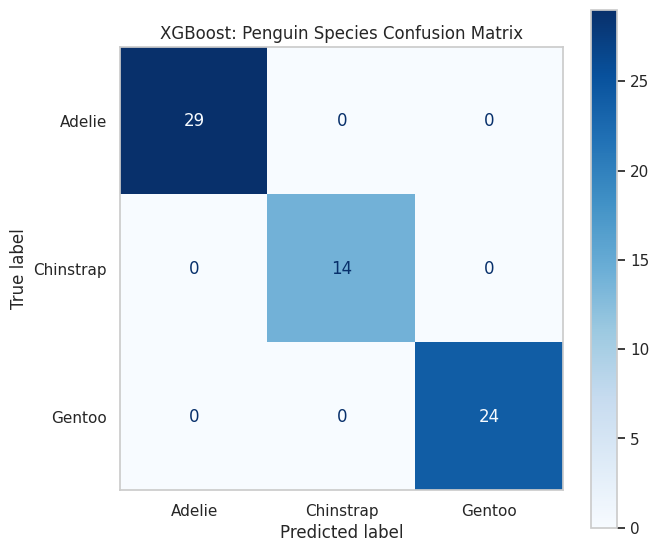

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=species_names,
    cmap="Blues",
    ax=ax
)
ax.set_title("XGBoost: Penguin Species Confusion Matrix", fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

### Reading the Matrix

Work through each row:

**Adelie row (top):** How many actual Adelie penguins were correctly identified? Which other species were they confused with?

**Chinstrap row (middle):** These penguins overlap with Adelie in body size. Look at whether the model confuses them — and which direction the confusion runs (Chinstrap → Adelie is the common direction).

**Gentoo row (bottom):** Gentoos are visually distinctive. If the model is working, this row should have almost all its count on the diagonal.

The confusion matrix reveals the *structure* of the model's errors — something a single accuracy number cannot.

In [8]:
# Per-species hit rates in plain numbers
cm = confusion_matrix(y_test, y_pred)

print("Per-species results on the test set:\n")
header = "  {:<12}  {:>8}  {:>6}  {:>9}".format("Species", "Correct", "Total", "Hit Rate")
print(header)
print("  " + "-" * (len(header) - 2))
for i, name in enumerate(species_names):
    correct = cm[i, i]
    total   = cm[i].sum()
    print("  {:<12}  {:>8}  {:>6}  {:>8.1%}".format(name, correct, total, correct / total))

Per-species results on the test set:

  Species        Correct   Total   Hit Rate
  -----------------------------------------
  Adelie              29      29    100.0%
  Chinstrap           14      14    100.0%
  Gentoo              24      24    100.0%


---

## Section 6: A First Look at the Classification Report

The `classification_report()` function neatly summarizes per-class performance. We will go deep on every number in the next notebook — for now, just orient yourself.

In [9]:
print(classification_report(y_test, y_pred, target_names=species_names))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



**A quick orientation:**

- Each of the first three rows corresponds to one species
- `support` (the rightmost column) is how many test samples belong to that class — the denominator behind every metric in that row
- The last two rows are averages across all classes — more on those next notebook

The important thing to notice right now: **the scores vary by class**. Each species has a different performance profile. Understanding why — and what to do about it — is what the next notebook is for.

## Putting It All Together

| Concept | What it means |
|---|---|
| Multiclass classification | A prediction problem with three or more possible outcomes |
| `objective="multi:softprob"` | Tells XGBoost to output one probability per class (using softmax internally) |
| Softmax | Converts K raw scores to K probabilities that sum to 1.0; used inside XGBoost and as the output layer of multiclass neural networks |
| Cross-entropy / log-loss | Measures how well predicted probabilities match true class labels; the standard training objective for both tree models and neural networks |
| `predict_proba()` | Returns an N×K matrix: N rows (one per sample), K columns (one per class); each row sums to 1.0 |
| Predicted class | Whichever class has the highest probability for that sample |
| K×K confusion matrix | Rows = actual classes, columns = predicted classes; diagonal = correct, off-diagonal = mistakes |
| Off-diagonal cell (row i, col j) | How many samples truly in class i were wrongly predicted as class j |

The story so far:

1. Multiclass problems have K ≥ 3 possible outcomes. Binary is just the K=2 special case.
2. XGBoost handles multiclass natively — set `objective="multi:softprob"` and `num_class=K`. Internally it uses softmax; externally you see probabilities that sum to 1.0.
3. The model outputs K probabilities per sample, always summing to 1.0. The highest wins.
4. The K×K confusion matrix reveals which class pairs the model confuses — something a single accuracy number cannot show.
5. Softmax, cross-entropy loss, and the probability-vector output format are not unique to XGBoost — they reappear as the foundation of multiclass neural networks.

**Where we are going next:** The confusion matrix shows *where* the model makes mistakes. The next notebook builds the metrics that quantify *how bad* those mistakes are, separately for each class.